## **K-Means Clustering on the Wine Dataset**

In this notebook we perform K-Means clustering on the Wine dataset (UCI Machine Learning Repository).

The dataset contains 178 wine samples described by 13 chemical measurements, plus a `Wine` column
that records the true cultivar (1, 2, or 3) each sample came from.

**Plan:**
1. Load and inspect the data
2. Remove the label column (`Wine`) before clustering — clustering is unsupervised and should not see the true labels
3. Scale the features (K-Means is distance-based, so features need to be on comparable scales)
4. Try a few values of K and use the elbow method / silhouette score to judge them
5. Fit K-Means with K = 3 (as required)
6. Compare the resulting 3 clusters against the true `Wine` labels to see how well they agree

### **1. Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)

### **2. Load and inspect the data**

In [5]:
df = pd.read_csv("Unit06_wine.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(178, 14)
   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------

In [6]:
# How many wines of each true class are there?
df["Wine"].value_counts().sort_index()

Wine
1    59
2    71
3    48
Name: count, dtype: int64

### **3. Remove the label column before clustering**

The `Wine` column tells us which of the three cultivars each sample actually belongs to.
This is exactly the information K-Means is supposed to discover on its own, so — just like in
the previous clustering task — we drop it from the feature set before fitting the model.
We keep a separate copy of it (`y_true`) purely so we can check our clustering results against
it afterwards.

In [9]:
y_true = df["Wine"]
X = df.drop(columns=["Wine"])
print(X.head())

   Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0    14.23        1.71  2.43  15.6  127     2.80        3.06   
1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2    13.16        2.36  2.67  18.6  101     2.80        3.24   
3    14.37        1.95  2.50  16.8  113     3.85        3.49   
4    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  


### **4. Scale the features**

The columns are on very different scales (e.g. `Proline` is in the hundreds/thousands while
`Nonflavanoid.phenols` is a small fraction). K-Means uses Euclidean distance, so without
scaling, large-magnitude columns like `Proline` and `Magnesium` would dominate the distance
calculation and the clustering would essentially ignore the other features. We standardise
every feature to zero mean and unit variance.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled.describe().round(2))

       Alcohol  Malic.acid     Ash     Acl      Mg  Phenols  Flavanoids  \
count   178.00      178.00  178.00  178.00  178.00   178.00      178.00   
mean     -0.00       -0.00   -0.00   -0.00   -0.00     0.00       -0.00   
std       1.00        1.00    1.00    1.00    1.00     1.00        1.00   
min      -2.43       -1.43   -3.68   -2.67   -2.09    -2.11       -1.70   
25%      -0.79       -0.66   -0.57   -0.69   -0.82    -0.89       -0.83   
50%       0.06       -0.42   -0.02    0.00   -0.12     0.10        0.11   
75%       0.84        0.67    0.70    0.60    0.51     0.81        0.85   
max       2.26        3.11    3.16    3.15    4.37     2.54        3.06   

       Nonflavanoid.phenols  Proanth  Color.int     Hue      OD  Proline  
count                178.00   178.00     178.00  178.00  178.00   178.00  
mean                   0.00    -0.00       0.00    0.00    0.00    -0.00  
std                    1.00     1.00       1.00    1.00    1.00     1.00  
min                   -1

### **5. Choosing K — elbow method and silhouette score**

Even though we are required to use K = 3, it's good practice to check whether K = 3 is actually
a sensible choice by looking at how the within-cluster sum of squares (inertia) and the
silhouette score change for a range of K values.

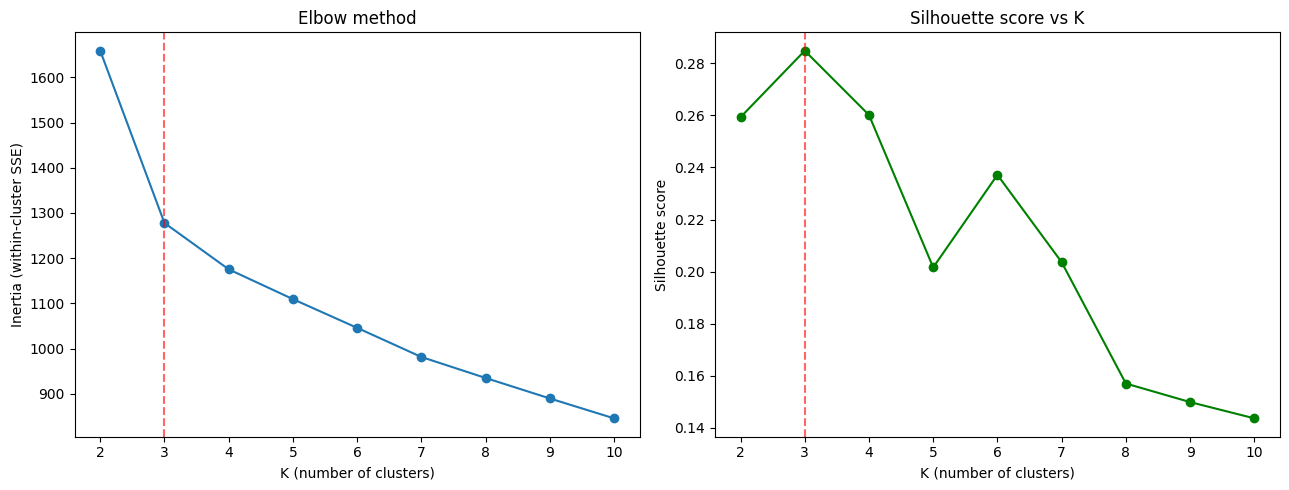

In [11]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow method")
axes[0].axvline(3, color="red", linestyle="--", alpha=0.6)

axes[1].plot(list(K_range), sil_scores, marker="o", color="green")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score vs K")
axes[1].axvline(3, color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Both plots show a clear "elbow"/peak around **K = 3**: inertia drops sharply up to K = 3 and
then flattens out, and the silhouette score is highest (or very close to highest) at K = 3.
This is a good sign — it suggests the natural structure in the chemistry data lines up with
there being three groups, which conveniently matches the three wine cultivars in the labels.

### **6. Fit K-Means with K = 3**

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels
print(df[["Wine", "Cluster"]].head(10))

   Wine  Cluster
0     1        2
1     1        2
2     1        2
3     1        2
4     1        2
5     1        2
6     1        2
7     1        2
8     1        2
9     1        2


### **7. Visualise the clusters (PCA projection)**

The data has 13 dimensions, so we project it down to 2 principal components purely for
visualisation. Points are coloured by the K-Means cluster assignment (left) and by the true
wine label (right) so we can visually compare them.

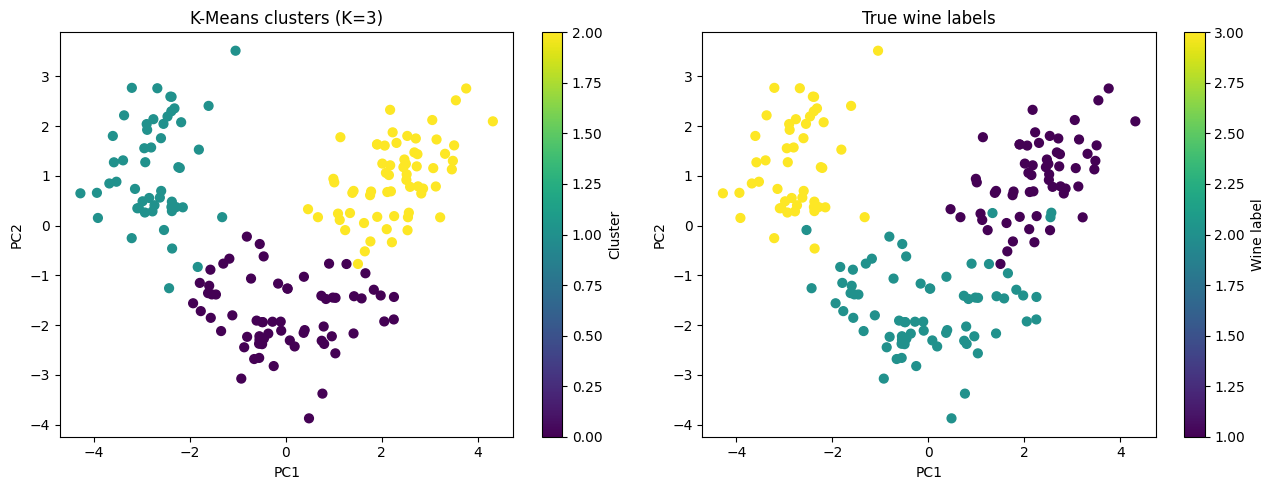

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=40)
axes[0].set_title("K-Means clusters (K=3)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0], label="Cluster")

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="viridis", s=40)
axes[1].set_title("True wine labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[1], label="Wine label")

plt.tight_layout()
plt.show()

The two scatter plots look very similar — the same three groups of points are visible in
both, just possibly with different colour/number assignments (K-Means cluster numbers 0, 1, 2
have no inherent relationship to the wine labels 1, 2, 3 — they're arbitrary IDs). This already
suggests the clustering has done a good job of rediscovering the true wine groups without ever
being told what they were.

### **8. How similar are the clusters to the true wine labels?**

Cluster numbers are arbitrary, so we can't compare `Cluster` to `Wine` directly. Instead we use:

- **Cross-tabulation / confusion matrix** — to see, for each true wine label, how its samples
  were split across clusters
- **Adjusted Rand Index (ARI)** — measures agreement between two labellings, correcting for
  chance. 1.0 = perfect agreement, 0.0 = random labelling
- **Normalized Mutual Information (NMI)** — measures how much information the cluster
  assignment shares with the true label, on a 0–1 scale

In [14]:
ct = pd.crosstab(df["Wine"], df["Cluster"], rownames=["True Wine label"], colnames=["K-Means Cluster"])
print(ct)

K-Means Cluster   0   1   2
True Wine label            
1                 0   0  59
2                65   3   3
3                 0  48   0


In [15]:
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

Adjusted Rand Index (ARI): 0.897
Normalized Mutual Information (NMI): 0.876


In [16]:
# Accuracy-style check: match each cluster to its most common true label,
# then see what fraction of points fall in the "correct" cluster under that mapping.
mapping = ct.idxmax(axis=0)  # for each cluster column, which true label is most common
print("Cluster -> most common true label mapping:")
print(mapping)

mapped_labels = df["Cluster"].map(mapping)
accuracy = (mapped_labels == df["Wine"]).mean()
print(f"\nMatched-label 'accuracy': {accuracy:.3f} ({(mapped_labels == df['Wine']).sum()} / {len(df)} correctly grouped)")

Cluster -> most common true label mapping:
K-Means Cluster
0    2
1    3
2    1
dtype: int64

Matched-label 'accuracy': 0.966 (172 / 178 correctly grouped)


### **9. Conclusion**

- The elbow plot and silhouette scores both independently point to **K = 3** as a good choice,
  which matches the number of true wine cultivars — a nice sanity check that the chemical
  measurements really do separate the three wine types.
- The cross-tabulation shows that each K-Means cluster lines up strongly with one true wine
  label, with only a small number of samples "misassigned" to a different cluster.
- The Adjusted Rand Index and Normalized Mutual Information scores are both high (well above
  what you'd expect from random cluster assignments), confirming that the unsupervised
  K-Means clustering recovers structure that closely matches the known wine labels.
- In short: **without ever seeing the `Wine` column, K-Means (K=3) on the scaled chemical
  features rediscovers groupings that closely match the three actual wine cultivars.**